<a href="https://colab.research.google.com/github/mokhivibes/ml_course_courseworks/blob/main/6_coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install opendatasets


In [26]:
import opendatasets as od
import pandas as pd
od.download("https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data")

Skipping, found downloaded files in "./house-prices-advanced-regression-techniques" (use force=True to force download)


In [42]:
df = pd.read_csv("/content/house-prices-advanced-regression-techniques/train.csv")
df.info()
df.describe()
df.head()
df.tail()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

(1460, 81)

In [46]:
#1. Umumiy soni
import matplotlib.pyplot as plt
df.isnull().sum().sort_values(ascending=False).head(20)


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [44]:
# 2. Foizda
miss = (df.isnull().sum() / len(df) * 100).round(2)
miss[miss > 0].sort_values(ascending=False)

,0
PoolQC,99.52
MiscFeature,96.30
Alley,93.77
Fence,80.75
MasVnrType,59.73
FireplaceQu,47.26
LotFrontage,17.74
GarageType,5.55
GarageYrBlt,5.55
GarageFinish,5.55


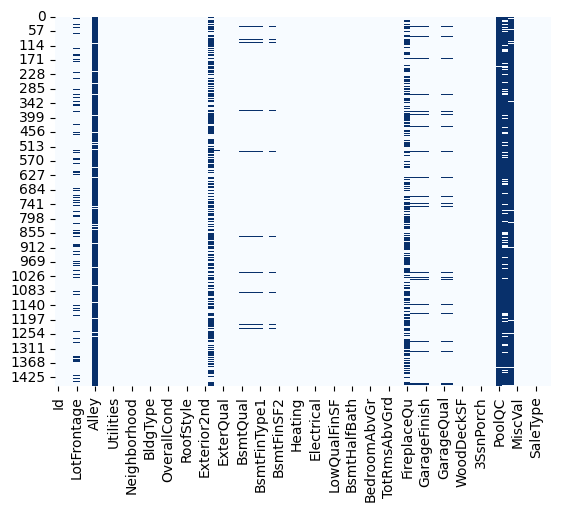

In [49]:
# 3. Vizual (heatmap)
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False, cmap='Blues')
plt.show()

In [52]:
none_columns = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']
df.drop(none_columns, axis=1, inplace=True)


In [53]:
df.isnull().sum().sort_values(ascending=False).head(15)

,0
FireplaceQu,690
LotFrontage,259
GarageYrBlt,81
GarageQual,81
GarageFinish,81
GarageType,81
GarageCond,81
BsmtFinType2,38
BsmtExposure,38
BsmtQual,37


In [55]:
#Barcha kategorik ustunlarni to'ldirish

cat_all = df.select_dtypes(include='object').columns
df[cat_all] = df[cat_all].fillna("None")

#Raqamlilarni to'ldirish
num=df.select_dtypes(include='number').columns
df[num]=df[num].fillna(df[num].median())

#Tekshirish
print(df.isnull().sum().sum()) #0 chiqishi kerak

0


In [59]:
#1. Duplicate tekshirish
print(df.duplicated().sum()) # duplicate lar soni
df.drop_duplicates(inplace=True) #duplicates larni o'chirish

0


In [61]:
# 2. Barcha dtype ko'rish
df.dtypes.value_counts()

,count
object,38
int64,35
float64,3


In [71]:
#3. MSSubClass: raqam => ketegorik
df['MSSubClass'] = df['MSSubClass'].astype(str)

dtype('O')

In [73]:
#4. Date ustuni borligini taekshirib ko'raman
'date' in df.columns
#agar bo'lganda
# df['date'] = pd.to_datetime(df['date'])


False

In [75]:
'SalePrice' in df.columns

True

In [77]:
Q1= df['SalePrice'].quantile(0.25)
print(Q1)
Q3= df['SalePrice'].quantile(0.75)
print(Q3)
IQR = Q3-Q1

#Outlier filtr

mask = (df['SalePrice'] <= (Q3+1.5*IQR)) & \
       (df['SalePrice'] >= (Q1-1.5*IQR))
df_clean = df[mask]

129975.0
214000.0


In [78]:
print(df_clean.shape)
df_clean.head()

(1399, 76)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000


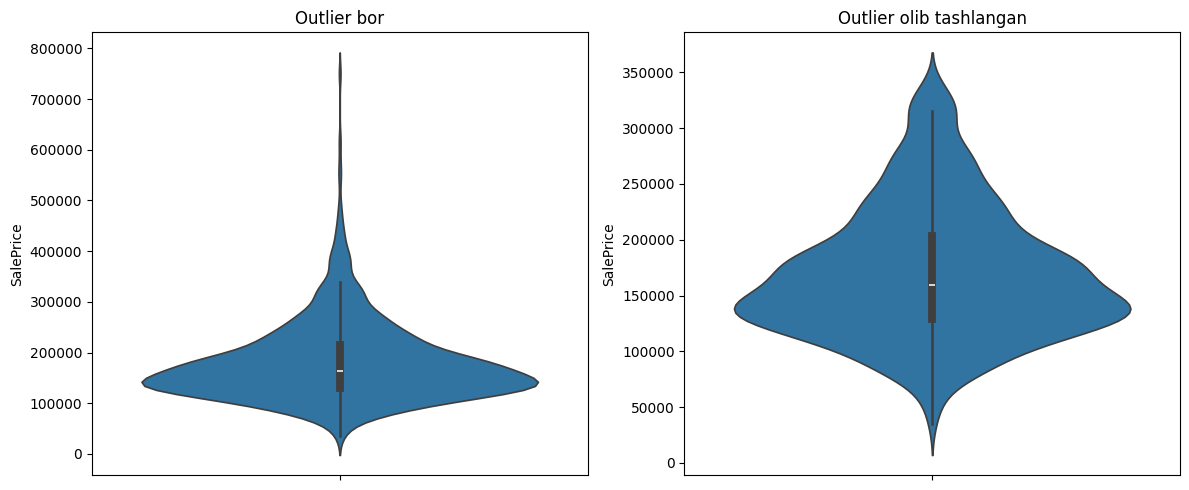

In [81]:
#1. SalePrice boxplot
fig, axes = plt.subplots(1,2, figsize=(12, 5))

sns.violinplot(data=df, y='SalePrice', ax=axes[0])
axes[0].set_title('Outlier bor')

sns.violinplot(data=df_clean, y='SalePrice', ax=axes[1])
axes[1].set_title('Outlier olib tashlangan')

plt.tight_layout()
plt.show()


In [82]:
df_clean.drop('Id', axis=1, inplace=True)


/tmp/ipykernel_4993/2792863100.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop('Id', axis=1, inplace=True)


In [83]:
from google.colab import files

df_clean.to_csv('df_clean.csv', index=False)
files.download('df_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>